# Method 1: Central Node as Source (CNS)

## Overview
Root node generates GHZ state and broadcasts data via quantum teleportation.

## Architecture
- **Node 0 (Root)**: Central hub, generates GHZ state
- **Nodes 1-6**: Client nodes receiving broadcast

## Phases
1. **GHZ Generation**: Root creates 7-qubit GHZ state
2. **Distribution**: Root keeps 1 qubit, sends 6 to clients
3. **Teleportation**: Root performs BSM on data qubit + GHZ qubit
4. **Broadcast**: Clients apply Pauli corrections based on measurement

In [3]:
import importlib
import MPI
import MPI_collective
importlib.reload(MPI_collective)
importlib.reload(MPI)

<module 'MPI' from '/home/tin_2/user_data/qmpi_cpe_kmutt/QMPI_Tinthai_Version/Star_Topology/MPI.py'>

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import math

In [5]:
def qdata_to_circuit(qc, qdata):
    # for inst, qargs, cargs in qdata:
    #     qc.append(inst, qargs, cargs)
    for instr in qdata:
        qc.append(instr.operation, instr.qubits, instr.clbits)

In [6]:
# # Setup: 7 nodes, 2 qubits each
# # Node 0 (Root): q0=data, q1=GHZ_root
# # Nodes 1-6: q_i=GHZ_client

# num_nodes = 7
# data_qubit = 0
# root_ghz = 1
# client_ghz = list(range(2, 2 + (num_nodes - 1)))  # [2,3,4,5,6,7]

# qr = QuantumRegister(1 + num_nodes, 'q')  # 1 data + 7 GHZ qubits
# cr_bsm = ClassicalRegister(2, 'bsm')  # BSM results
# cr_out = ClassicalRegister(num_nodes - 1, 'out')  # Client outputs
# qc = QuantumCircuit(qr, cr_bsm, cr_out)

# print(f"Data qubit: {data_qubit}")
# print(f"Root GHZ qubit: {root_ghz}")
# print(f"Client GHZ qubits: {client_ghz}")

In [10]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

sendqc_circuit = QuantumCircuit()

nodes = []
nodes_epr = []
nodes_epr_creg = []

for i in range(0, 7):
    n = QuantumRegister(1, name=f"node{i}")
    nodes.append(n)
    num_epr_qubits = 2
    n_epr = QuantumRegister(num_epr_qubits, name=f"node{i}_epr")
    nodes_epr.append(n_epr)
    n_creg = ClassicalRegister(1, name=f"node{i}_epr_creg")
    nodes_epr_creg.append(n_creg)
    sendqc_circuit.add_register(n, n_epr, n_creg)

epr_c = ClassicalRegister(2, name="epr_cr")
sendqc_circuit.add_register(epr_c)

print(f"Added {len(nodes)} nodes to the circuit.")

Added 7 nodes to the circuit.


In [11]:
# Prepare data qubit (message to broadcast)
# Example: |+⟩ state
# qc.h(data_qubit)
sendqc_circuit.rx(math.pi/4, nodes[0][0]) 
sendqc_circuit.ry(math.pi/4, nodes[0][0]) 
sendqc_circuit.barrier(label='Data Ready')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=21, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "node0"), index=0>, <Qubit register=(2, "node0_epr"), index=0>, <Qubit register=(2, "node0_epr"), index=1>, <Qubit register=(1, "node1"), index=0>, <Qubit register=(2, "node1_epr"), index=0>, <Qubit register=(2, "node1_epr"), index=1>, <Qubit register=(1, "node2"), index=0>, <Qubit register=(2, "node2_epr"), index=0>, <Qubit register=(2, "node2_epr"), index=1>, <Qubit register=(1, "node3"), index=0>, <Qubit register=(2, "node3_epr"), index=0>, <Qubit register=(2, "node3_epr"), index=1>, <Qubit register=(1, "node4"), index=0>, <Qubit register=(2, "node4_epr"), index=0>, <Qubit register=(2, "node4_epr"), index=1>, <Qubit register=(1, "node5"), index=0>, <Qubit register=(2, "node5_epr"), index=0>, <Qubit register=(2, "node5_epr"), index=1>, <Qubit register=(1, "node6"), index=0>, <Qubit register=(2, "node6_epr"), index=0>, <Qubit register=(2, "node6_epr"), index=1>

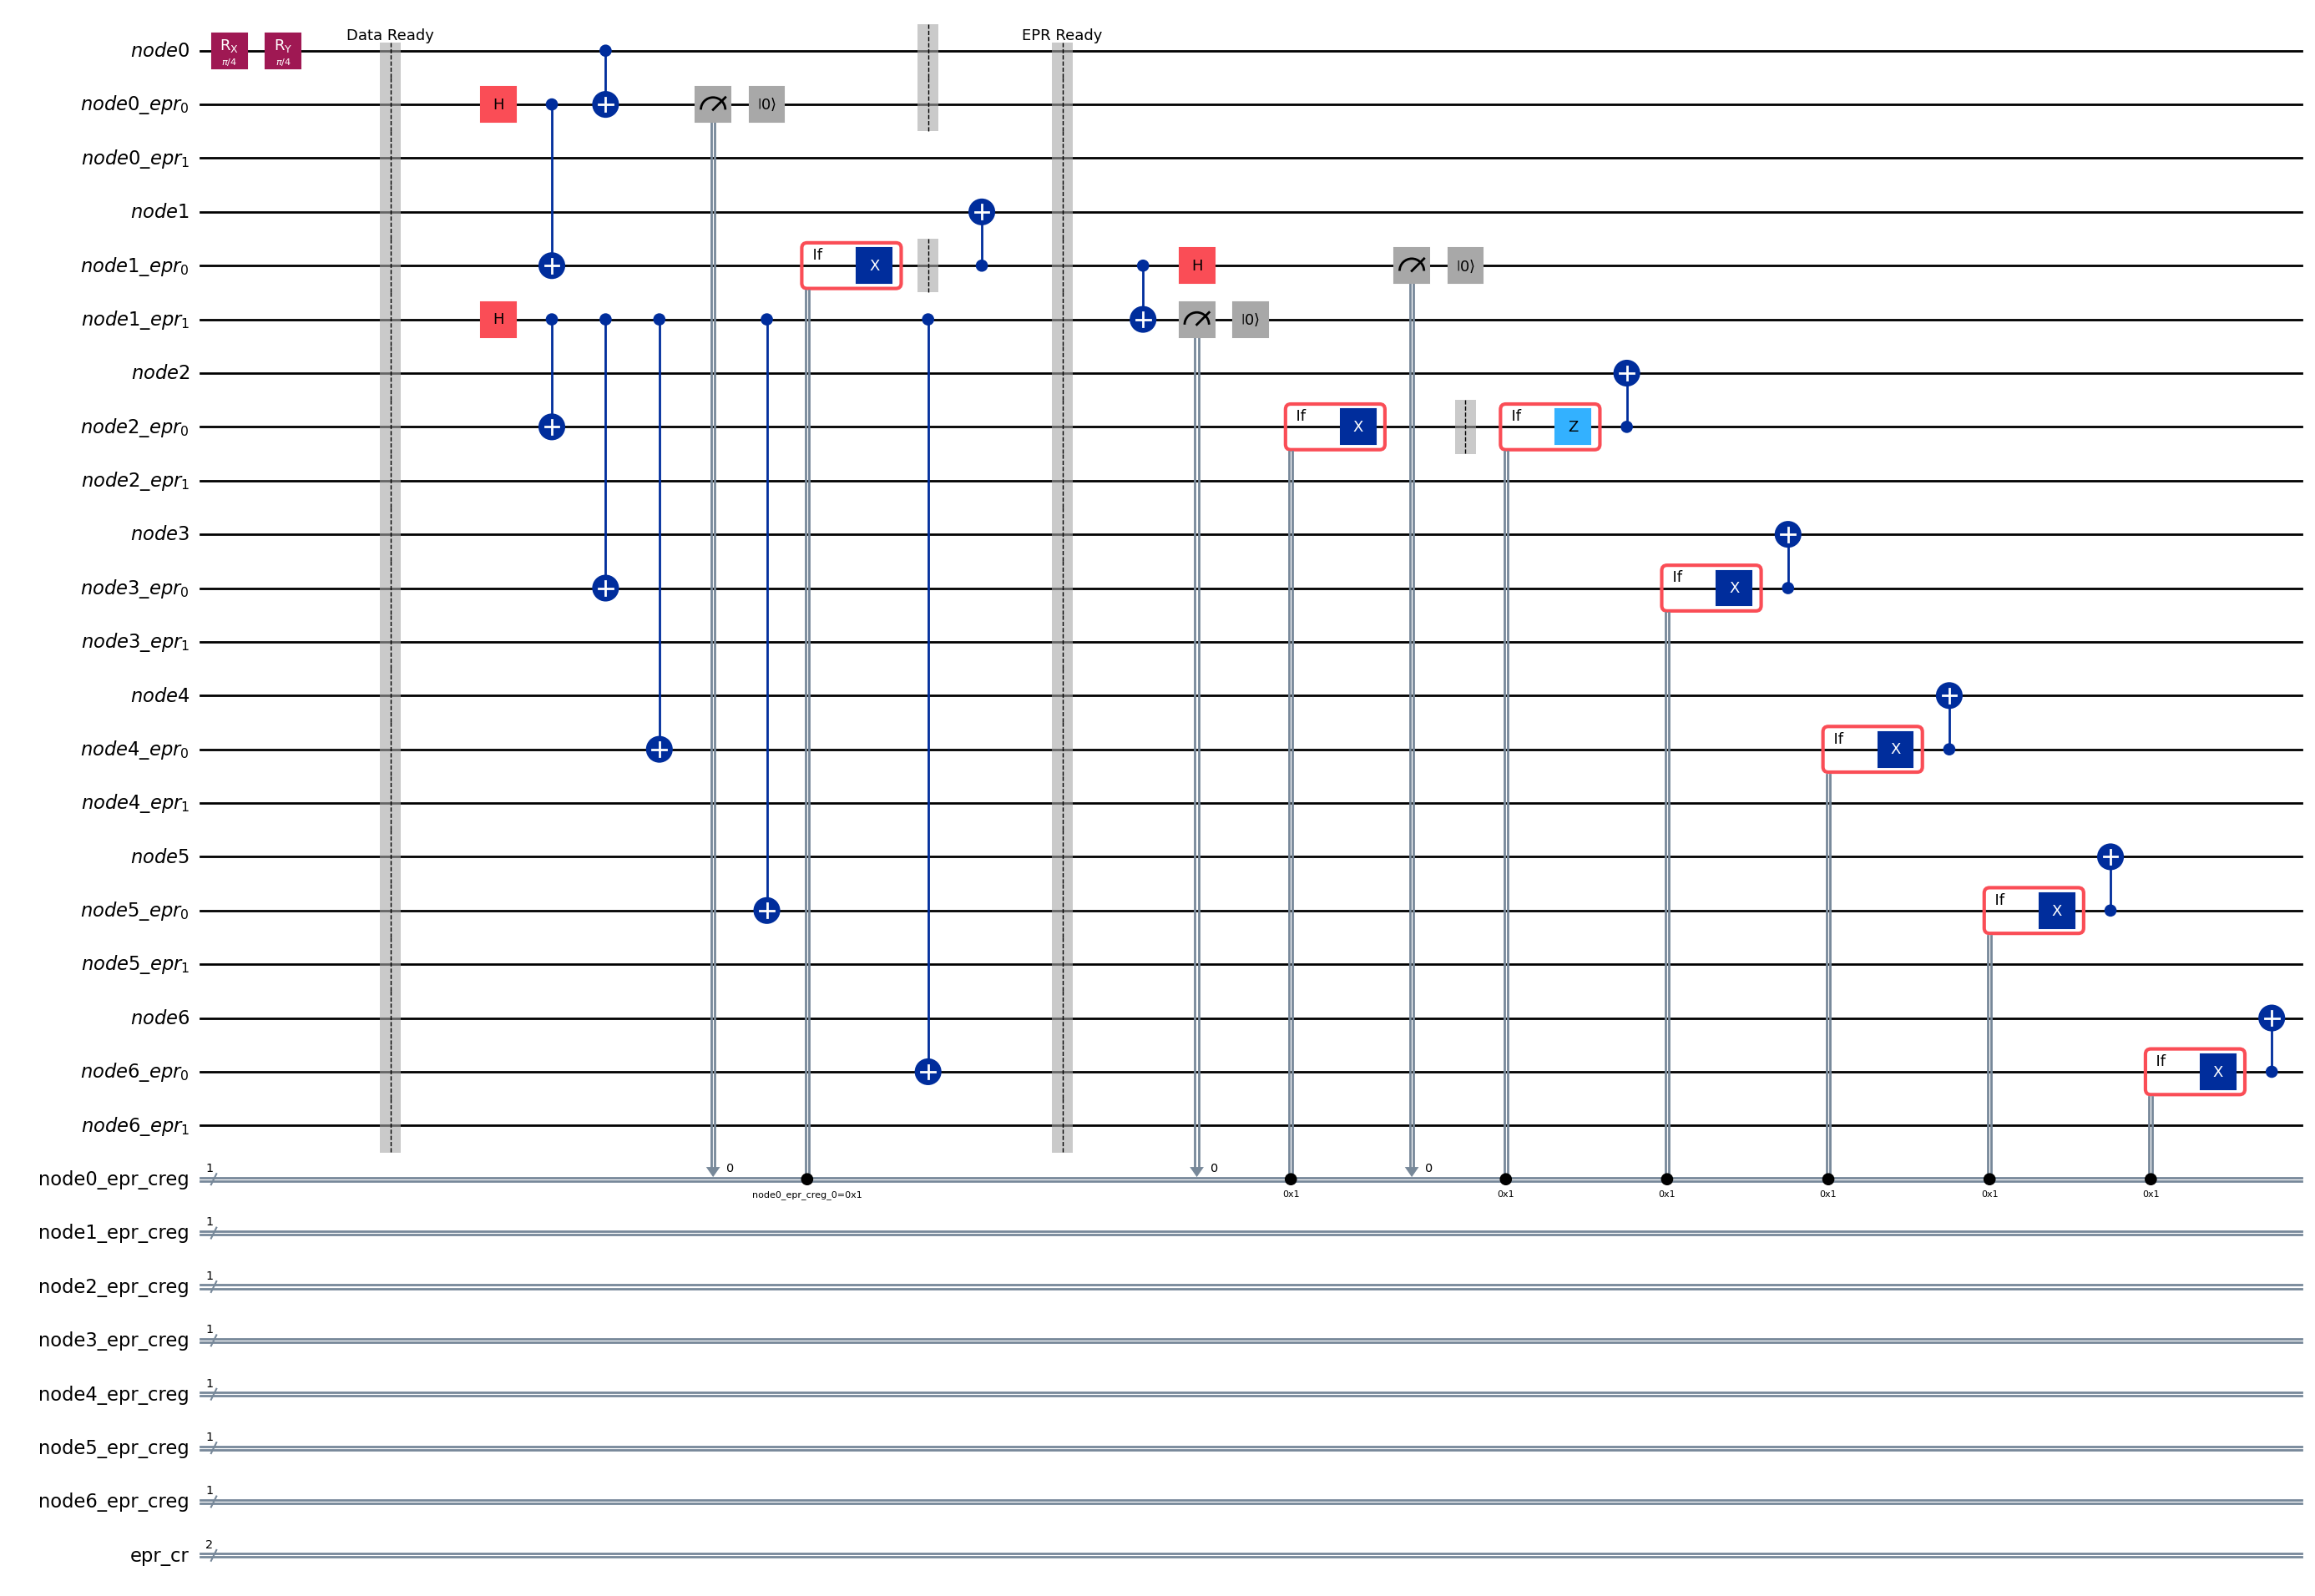

In [12]:
sendqc_epr_class = MPI.EPRsetup(sendqc_circuit, nodes[0][0], nodes[1][0])
sendqc_epr_class.q

sendqc_epr_class.q.h(nodes_epr[1][1])  # Root GHZ qubit
for i in range(2, 7):
    sendqc_epr_class.q.cx(nodes_epr[1][1], nodes_epr[i][0])  # Root GHZ qubit -> Client GHZ qubits

# Copy from Node 0 to Node 1
operation = sendqc_epr_class.copy()
qdata_to_circuit(sendqc_epr_class.q, operation)
sendqc_epr_class.q.cx(nodes_epr[1][0], nodes[1][0])

sendqc_epr_class.q.barrier(label='EPR Ready')
sendqc_epr_class.q.cx(nodes_epr[1][0], nodes_epr[1][1])  # Root GHZ qubit -> Data qubit
sendqc_epr_class.q.h(nodes_epr[1][0])  # Node 1 GHZ qubit

sendqc_epr_class.q.measure(nodes_epr[1][1], nodes_epr_creg[0])  # Measure Root GHZ qubit
sendqc_epr_class.q.reset(nodes_epr[1][1])
with sendqc_epr_class.q.if_test((nodes_epr_creg[0],1)):
        sendqc_epr_class.q.x(nodes_epr[2][0])

sendqc_epr_class.q.measure(nodes_epr[1][0], nodes_epr_creg[0])
sendqc_epr_class.q.barrier(nodes_epr[2][0])
with sendqc_epr_class.q.if_test((nodes_epr_creg[0],1)):
        sendqc_epr_class.q.z(nodes_epr[2][0])
sendqc_epr_class.q.reset(nodes_epr[1][0])
sendqc_epr_class.q.cx(nodes_epr[2][0], nodes[2][0])

with sendqc_epr_class.q.if_test((nodes_epr_creg[0],1)):
        sendqc_epr_class.q.x(nodes_epr[3][0])
sendqc_epr_class.q.cx(nodes_epr[3][0], nodes[3][0])
with sendqc_epr_class.q.if_test((nodes_epr_creg[0],1)):
        sendqc_epr_class.q.x(nodes_epr[4][0])
sendqc_epr_class.q.cx(nodes_epr[4][0], nodes[4][0])
with sendqc_epr_class.q.if_test((nodes_epr_creg[0],1)):
        sendqc_epr_class.q.x(nodes_epr[5][0])
sendqc_epr_class.q.cx(nodes_epr[5][0], nodes[5][0])
with sendqc_epr_class.q.if_test((nodes_epr_creg[0],1)):
        sendqc_epr_class.q.x(nodes_epr[6][0])
sendqc_epr_class.q.cx(nodes_epr[6][0], nodes[6][0])

sendqc_circuit.draw('mpl', fold=-1)

Circuit depth: 19
Circuit size: 26


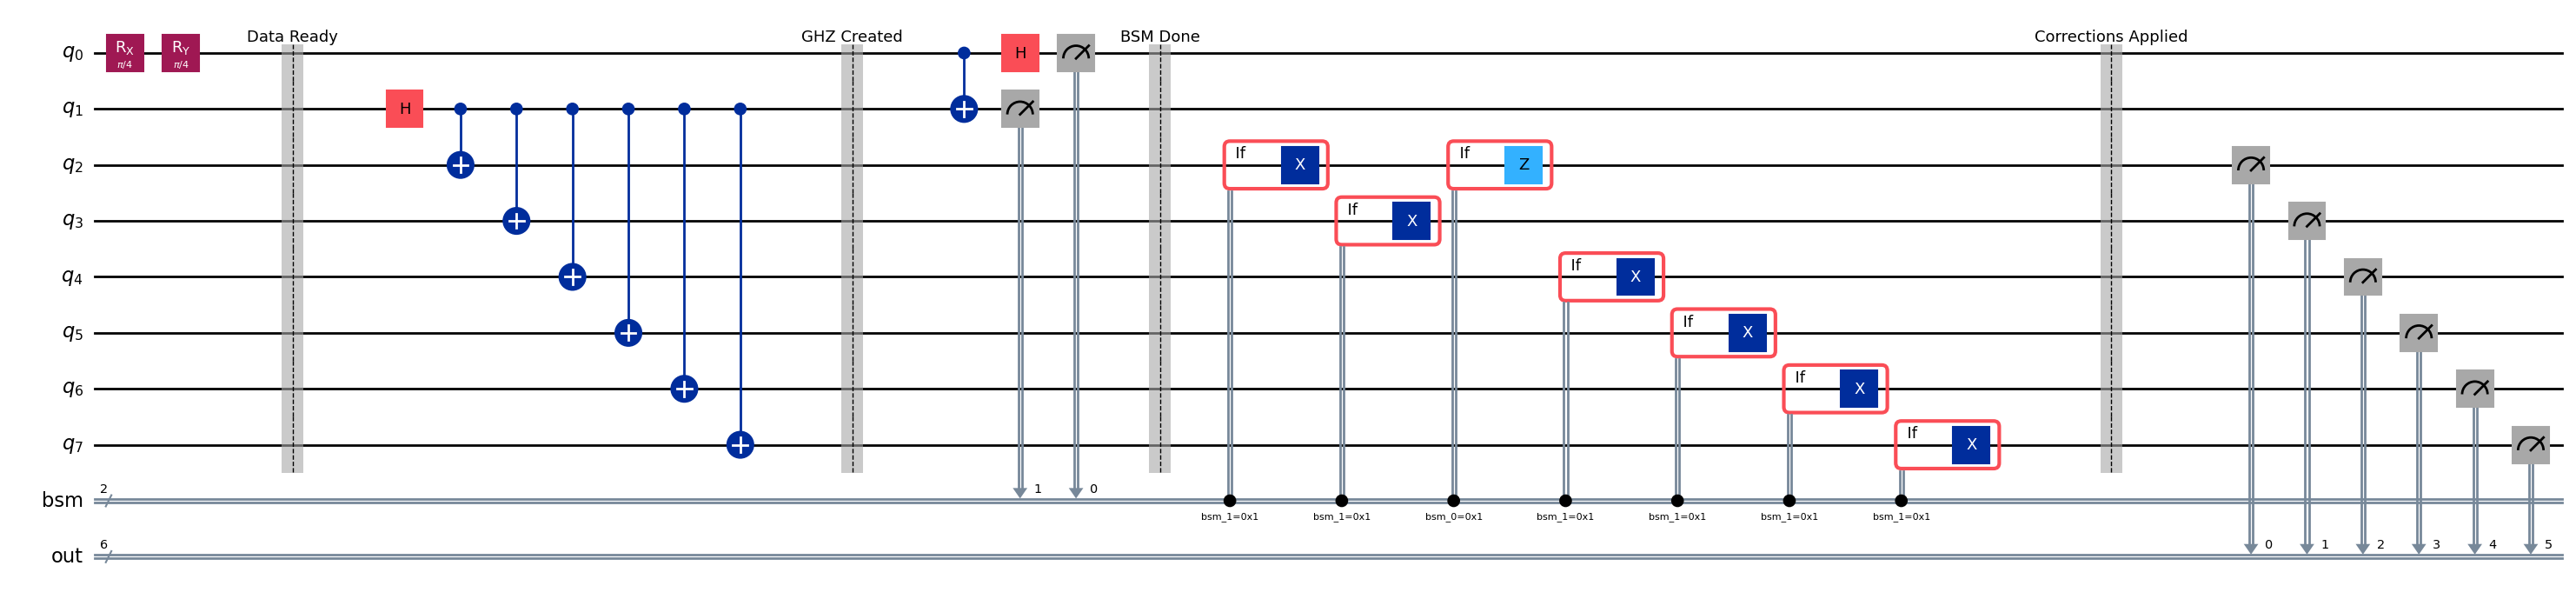

In [11]:
# Measure client qubits
for i, client_q in enumerate(client_ghz):
    qc.measure(client_q, cr_out[i])

print(f"Circuit depth: {qc.depth()}")
print(f"Circuit size: {qc.size()}") 
qc.draw('mpl', fold=-1)

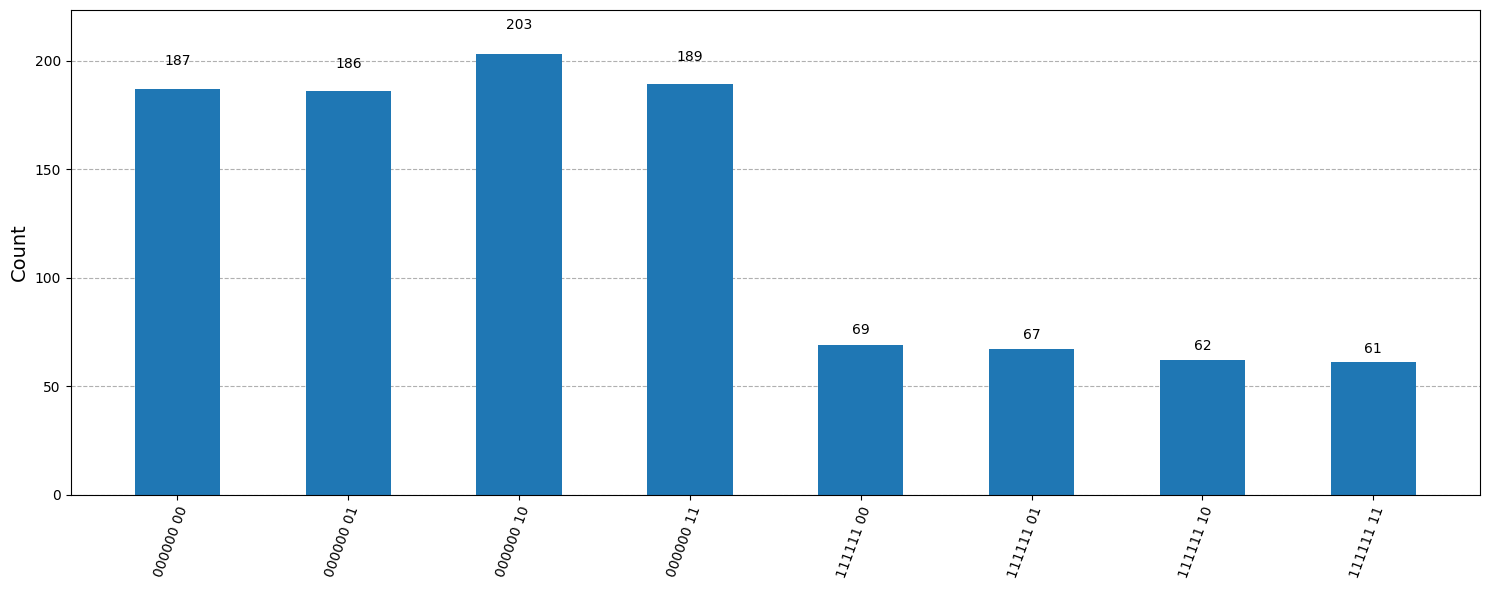

In [12]:
# Simulate
backend = AerSimulator()
job = backend.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

plot_histogram(counts, figsize=(15, 6))

In [267]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.quantum_info import Statevector
import numpy as np

# 1 ลบการวัดออก (เพื่อดูสถานะก่อน collapse)
circ_no_measure = sendqc_epr_class.q.remove_final_measurements(inplace=False)

# 2 บอกให้ simulator เก็บ statevector
circ_no_measure.save_statevector() 

# 3 ใช้ simulator แบบ statevector
sim_sv = AerSimulator(method='statevector')

# 4 transpile และรัน
ready_sv = transpile(circ_no_measure, sim_sv)
result_sv = sim_sv.run(ready_sv).result()

# 5 ดึงข้อมูล statevector ออกมา
statevector = result_sv.data(0)['statevector']
# print(statevector)

# statevector จากผล simulation
vec = Statevector(statevector)

# แสดงเฉพาะค่าสำคัญ
for i, amp in enumerate(vec.data):
    if not np.isclose(abs(amp), 0):  # ข้ามค่าที่แทบเป็นศูนย์
        print(f"|{i:0{vec.num_qubits}b}> : {amp}")

|000000000000000000000> : (0.8535533905932738+0.1464466094067263j)
|011011011011011001001> : (0.3535533905932736-0.3535533905932736j)


In [14]:
# Analysis
print("\n=== Broadcast Results ===")
print(f"Expected: All clients receive same state as original data qubit")
print(f"\nTop 10 outcomes:")
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10]
for state, count in sorted_counts:
    # Format: 'client_outputs bsm_results'
    print(f"{state}: {count} ({100*count/1024:.1f}%)")


=== Broadcast Results ===
Expected: All clients receive same state as original data qubit

Top 10 outcomes:
000000 10: 203 (19.8%)
000000 11: 189 (18.5%)
000000 00: 187 (18.3%)
000000 01: 186 (18.2%)
111111 00: 69 (6.7%)
111111 01: 67 (6.5%)
111111 10: 62 (6.1%)
111111 11: 61 (6.0%)


## Results

- Root broadcasts quantum state to all 6 clients simultaneously
- All clients receive identical copy of original data qubit
- Uses GHZ entanglement + quantum teleportation
- Requires 2 classical bits broadcast from root

In [15]:
!pip install qiskit qiskit-aer

In [269]:
from supermarq import *
import supermarq.converters as converters
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister

sim = AerSimulator()
star_topology_ghz = transpile(sendqc_epr_class.q, backend=sim, optimization_level=3)

bcast_tinthai = [
    features.compute_communication_with_qiskit(star_topology_ghz),
    features.compute_depth_with_qiskit(star_topology_ghz),
    features.compute_entanglement_with_qiskit(star_topology_ghz),
]

print("Metrics calculated successfully!")
print(f"Communication: {bcast_tinthai[0]}")
print(f"Depth: {bcast_tinthai[1]}")
print(f"Entanglement: {bcast_tinthai[2]}")

Metrics calculated successfully!
Communication: 0.06666666666666667
Depth: 0.5
Entanglement: 0.7777777777777778


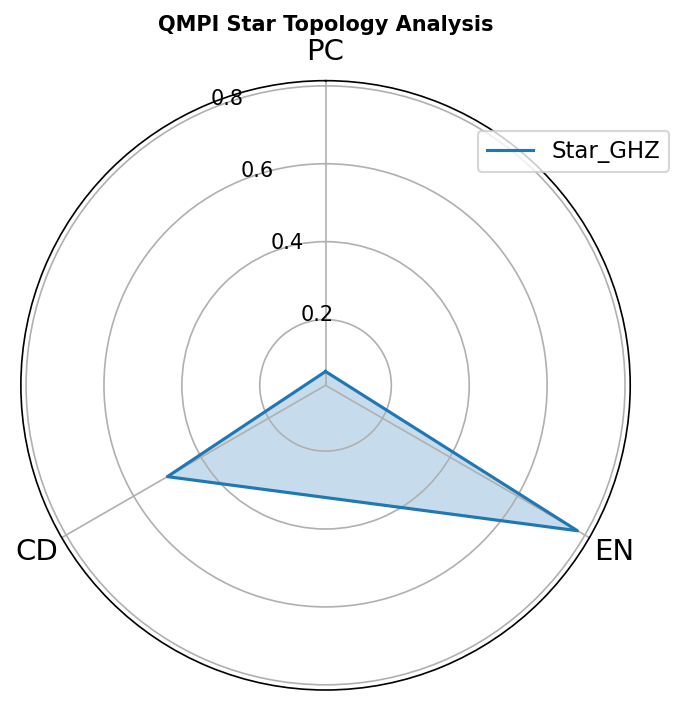

In [280]:
import supermarq

# 1. เตรียมข้อมูล Metric (ต้องมี 6 ค่าเพื่อให้ Radar Chart สมบูรณ์)
# เรียงลำดับตามนี้: [PC, CD, Ent, Liv, Mea, Par]
# PC = Program Communication
# CD = Critical Depth
# Ent = Entanglement
# Liv = Liveness
# Mea = Measurement
# Par = Parallelism

# นำค่าที่คุณคำนวณได้ใส่เข้าไป (ตัวไหนไม่ได้คำนวณให้ใส่ 0 ไปก่อน)
star_ghz_features = [
    bcast_tinthai[0], # PC
    bcast_tinthai[1], # CD
    bcast_tinthai[2], # Ent
]

# 2. ใช้คำสั่งพลอตเวอร์ชันล่าสุด
supermarq.plotting.plot_benchmark(
    title="QMPI Star Topology Analysis", 
    labels=["Star_GHZ"], 
    features=[star_ghz_features],
    spoke_labels=["PC", "CD", "EN"]
)